In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [13]:
# STEP 1: Load the local data safely
df = pd.read_csv('bank.csv', sep=None, engine='python')

# 2. Check the real name of your last column automatically
# If it is 'y', we change it. If it's already 'Accepted_Offer', we leave it alone.
if 'y' in df.columns:
    df = df.rename(columns={'y': 'Accepted_Offer'})
elif 'Accepted_Offer' not in df.columns:
    # Fallback: If it's named something else entirely (like 'deposit'), rename the very last column
    last_col_name = df.columns[-1]
    df = df.rename(columns={last_col_name: 'Accepted_Offer'})

print("--- Verified Available Columns ---")
print(df.columns.tolist()[:10]) # Prints the first few columns to confirm
print(f"Target column successfully verified as: 'Accepted_Offer'")

--- Verified Available Columns ---
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day']
Target column successfully verified as: 'Accepted_Offer'


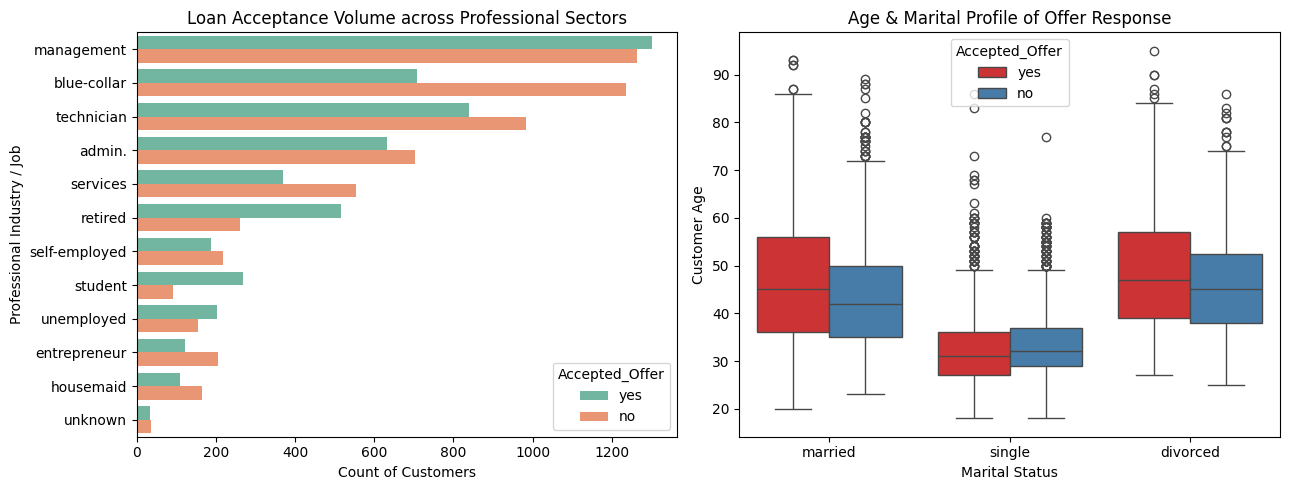

In [12]:
# STEP 2: PLOT THE VISUALIZATIONS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graph 1: Job Type vs Loan Acceptance Status
sns.countplot(data=df, y='job', hue='Accepted_Offer', palette='Set2', 
              order=df['job'].value_counts().index, ax=axes[0])
axes[0].set_title('Loan Acceptance Volume across Professional Sectors')
axes[0].set_xlabel('Count of Customers')
axes[0].set_ylabel('Professional Industry / Job')

# Graph 2: Marital Status vs Age Distribution Split
sns.boxplot(data=df, x='marital', y='age', hue='Accepted_Offer', palette='Set1', ax=axes[1])
axes[1].set_title('Age & Marital Profile of Offer Response')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Customer Age')

plt.tight_layout()
plt.show()

In [14]:
# STEP 3: CATEGORICAL ENCODING & DATA SPLIT
# =====================================================================
# Map target responses: Convert 'yes' to 1 and 'no' to 0 safely
if df['Accepted_Offer'].dtype == 'object':
    df['Accepted_Offer'] = df['Accepted_Offer'].map({'yes': 1, 'no': 0})

# Select core demographic and financial features for the model
feature_cols = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan']
X_raw = df[feature_cols]
y = df['Accepted_Offer']

# Convert text groups into numerical 0 and 1 columns using One-Hot Encoding
X = pd.get_dummies(X_raw, drop_first=True)

# Partition into an 80% training set and a 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
# STEP 4: MODEL TRAINING & FINAL PERFORMANCE EVALUATION
# =====================================================================
# Train a Decision Tree with a depth constraint to keep it highly generalizable
capstone_model = DecisionTreeClassifier(max_depth=5, random_state=42)
capstone_model.fit(X_train, y_train)

# Test the model on the hidden 20% test data
y_pred = capstone_model.predict(X_test)

print("     CAPSTONE: PERSONAL LOAN MODEL RESULTS        ")
print(f"Targeted Campaign Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Metrics Breakdown:")
print(classification_report(y_test, y_pred))

     CAPSTONE: PERSONAL LOAN MODEL RESULTS        
Targeted Campaign Accuracy: 64.13%

Classification Metrics Breakdown:
              precision    recall  f1-score   support

          no       0.66      0.64      0.65      1166
         yes       0.62      0.64      0.63      1067

    accuracy                           0.64      2233
   macro avg       0.64      0.64      0.64      2233
weighted avg       0.64      0.64      0.64      2233



In [21]:
# PREDICT LOAN ACCEPTANCE FOR A NEW CUSTOMER

def predict_custom_customer(age, job, marital, education, balance, housing, loan):
    """
    Takes raw customer demographics, aligns them with the trained model's 
    encoded structure, and returns a live prediction.
    """
    # 1. Create a single-row DataFrame using the user's inputs
    new_customer = pd.DataFrame([{
        'age': age,
        'job': job,
        'marital': marital,
        'education': education,
        'balance': balance,
        'housing': housing,
        'loan': loan
    }])
    
    # 2. Re-apply One-Hot Encoding to match our training structure
    new_customer_encoded = pd.get_dummies(new_customer)
    
    # 3. Force this new row to have the exact same columns as our model's X matrix
    # Fill any missing columns (like other job categories) with 0
    new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)
    
    # 4. Generate the prediction and probability
    pred = capstone_model.predict(new_customer_encoded)[0]
    prob = capstone_model.predict_proba(new_customer_encoded)[0][1]
    
    # 5. Print a beautiful business intelligence card
    print("         🔮 AI PREDICTION ENGINE          ")
    print(f"📊 Profile: {age}yo, {marital} {job} | Balance: ${balance:,}")
    print(f"🏠 Housing Loan: {housing.upper()} | 💳 Personal Loan: {loan.upper()}")
    print(f"📈 Conversion Probability: {prob * 100:.2f}%")    
    if pred == 1:
        print("🚨 RESULT: HIGHLY LIKELY TO ACCEPT THE LOAN!")
        print("👉 Action: Include this profile in the premium marketing list.")
    else:
        print("❌ RESULT: LIKELY TO REJECT.")
        print("👉 Action: Exclude to save campaign budget and prevent spam.")

# TEST YOUR RANDOM VALUES HERE!
# Syntax: predict_custom_customer(age, job, marital, education, balance, housing, loan)
# (Available strings for jobs: 'management', 'technician', 'blue-collar', 'admin.', 'services', etc.)

predict_custom_customer(
    age=38, 
    job='management', 
    marital='single', 
    education='tertiary', 
    balance=4500, 
    housing='no', 
    loan='no'
)

         🔮 AI PREDICTION ENGINE          
📊 Profile: 38yo, single management | Balance: $4,500
🏠 Housing Loan: NO | 💳 Personal Loan: NO
📈 Conversion Probability: 62.88%
❌ RESULT: LIKELY TO REJECT.
👉 Action: Exclude to save campaign budget and prevent spam.
